# PRCP-1003-Customer Transaction Prediction

## Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

## Loading Dataset

In [3]:
df=pd.read_csv("train(1).csv")
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [3]:
df.tail()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199995,train_199995,0,11.4880,-0.4956,8.2622,3.5142,10.3404,11.6081,5.6709,15.1516,...,6.1415,13.2305,3.9901,0.9388,18.0249,-1.7939,2.1661,8.5326,16.6660,-17.8661
199996,train_199996,0,4.9149,-2.4484,16.7052,6.6345,8.3096,-10.5628,5.8802,21.5940,...,4.9611,4.6549,0.6998,1.8341,22.2717,1.7337,-2.1651,6.7419,15.9054,0.3388
199997,train_199997,0,11.2232,-5.0518,10.5127,5.6456,9.3410,-5.4086,4.5555,21.5571,...,4.0651,5.4414,3.1032,4.8793,23.5311,-1.5736,1.2832,8.7155,13.8329,4.1995
199998,train_199998,0,9.7148,-8.6098,13.6104,5.7930,12.5173,0.5339,6.0479,17.0152,...,2.6840,8.6587,2.7337,11.1178,20.4158,-0.0786,6.7980,10.0342,15.5289,-13.9001
199999,train_199999,0,10.8762,-5.7105,12.1183,8.0328,11.5577,0.3488,5.2839,15.2058,...,8.9842,1.6893,0.1276,0.3766,15.2101,-2.4907,-2.2342,8.1857,12.1284,0.1385


In [4]:
df.columns

Index(['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4',
       'var_5', 'var_6', 'var_7',
       ...
       'var_190', 'var_191', 'var_192', 'var_193', 'var_194', 'var_195',
       'var_196', 'var_197', 'var_198', 'var_199'],
      dtype='object', length=202)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


### checking size of the dataset

In [6]:
df.shape

(200000, 202)

### The Dataset contains 200000 Rows and 201 Columns

In [7]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [8]:
df.isnull().sum().sum()

np.int64(0)

## No null values present

In [9]:
df.duplicated().sum()

np.int64(0)

## No duplicate values are present

# Target Variable Analysis

In [10]:
df["target"].value_counts()

target
0    179902
1     20098
Name: count, dtype: int64

- **0 Represent --> CUSTOMER DID NOT DO A TRANSACTION.**
- **1 Represent --> CUSTOMER DID DO THE TRANSACTION.**

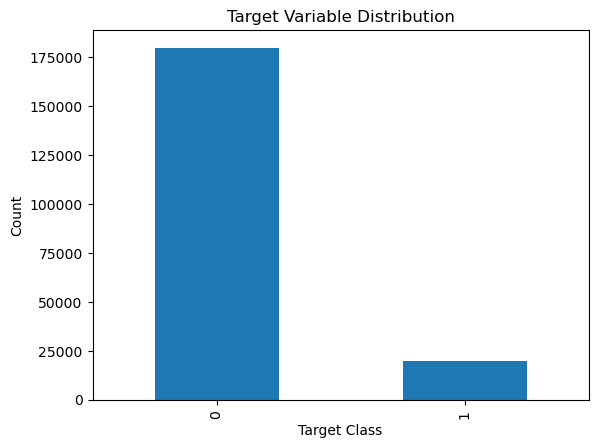

In [11]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.title('Target Variable Distribution')
plt.show()

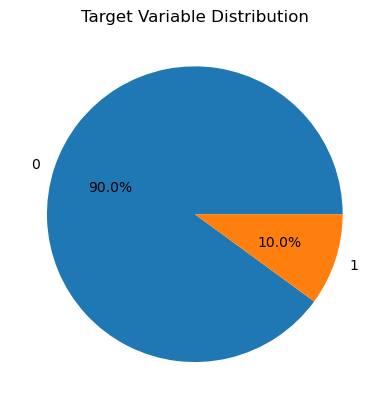

In [12]:
target_counts = df['target'].value_counts()

plt.figure()
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%')
plt.title('Target Variable Distribution')
plt.show()

### **The dataset is highly imbalanced, with 90% of samples belonging to Class 0 and only 10% to Class 1. This imbalance may affect model performance and requires appropriate handling techniques such as resampling or class weighting.**

# Note:

#### **We will skip the EDA part in this project as feature names are not provided because the data contains private information of customers of Bank.**

# Checking Distribution for first 100 Columns

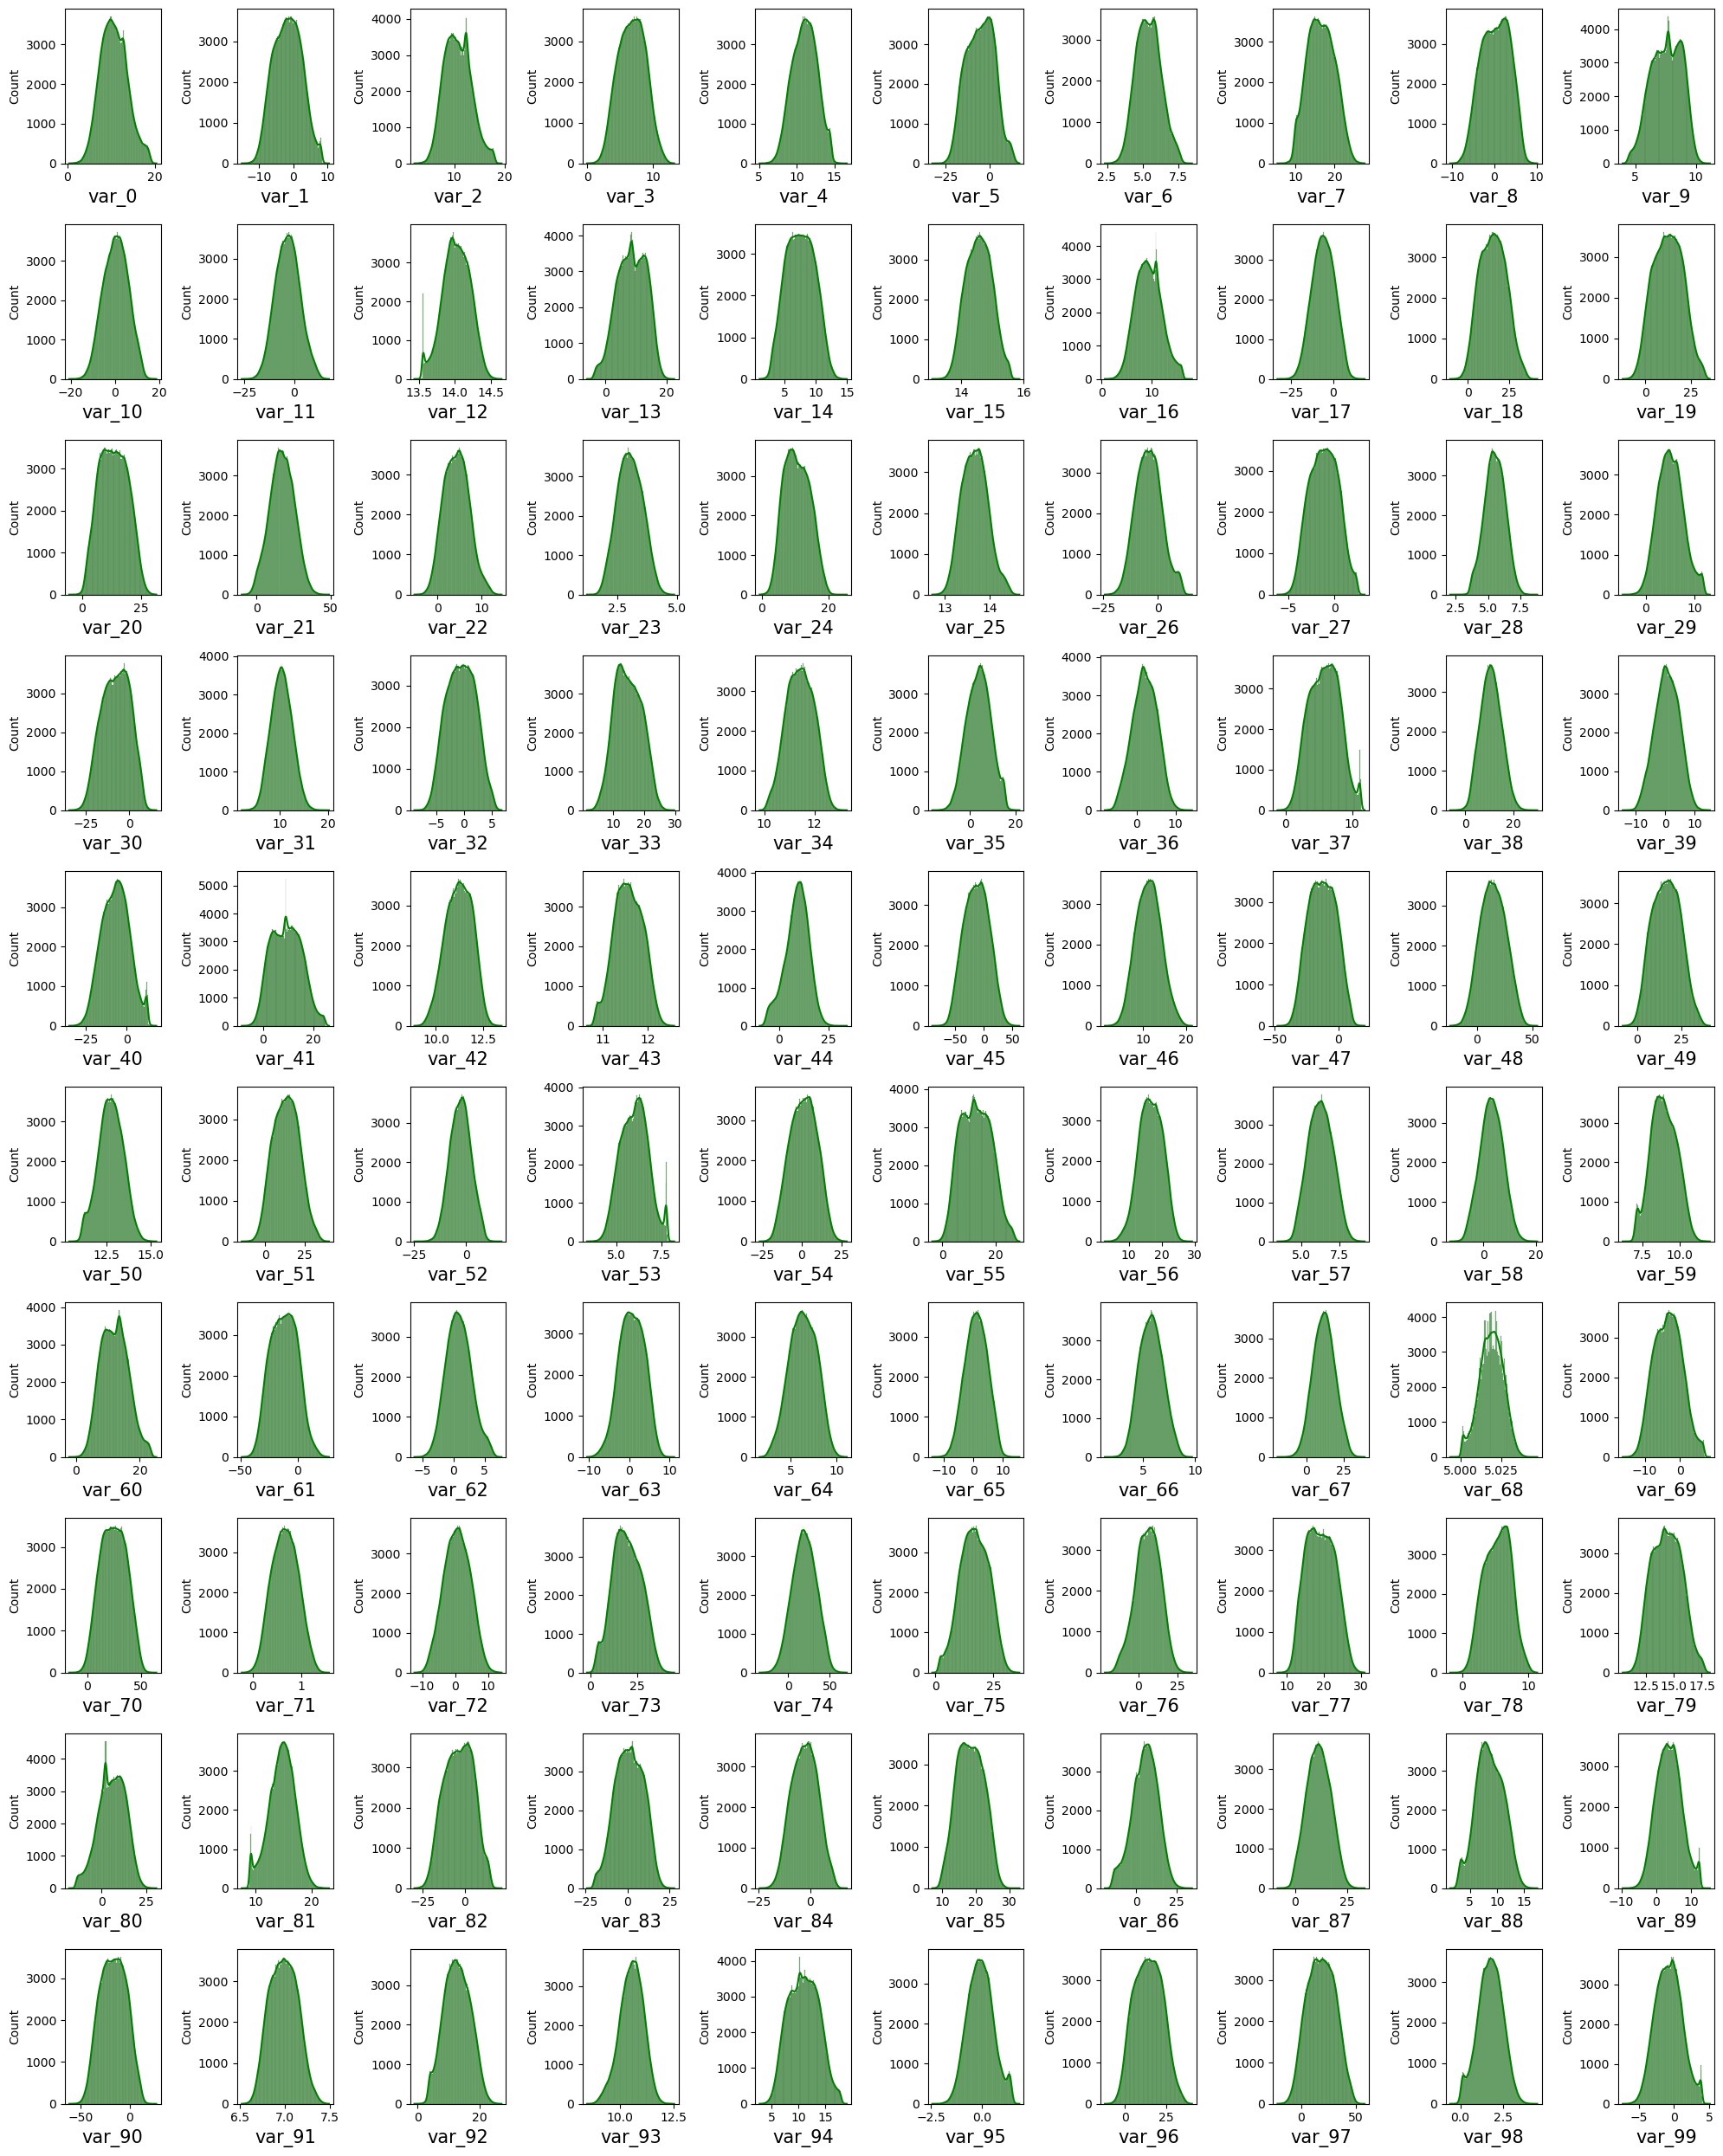

In [13]:
dist = df.iloc[:,2:102]
plt.figure(figsize=(20,25),facecolor='white') 
plotno = 1 # counter
for column in dist: 
    if plotno<=100: 
        plt.subplot(10,10,plotno) 
        sns.histplot(dist[column],kde=True,color='green')
        plt.xlabel(column,fontsize=15) 
    plotno+=1
plt.tight_layout()
plt.show() 

# Checking Distribution for remaining Columns

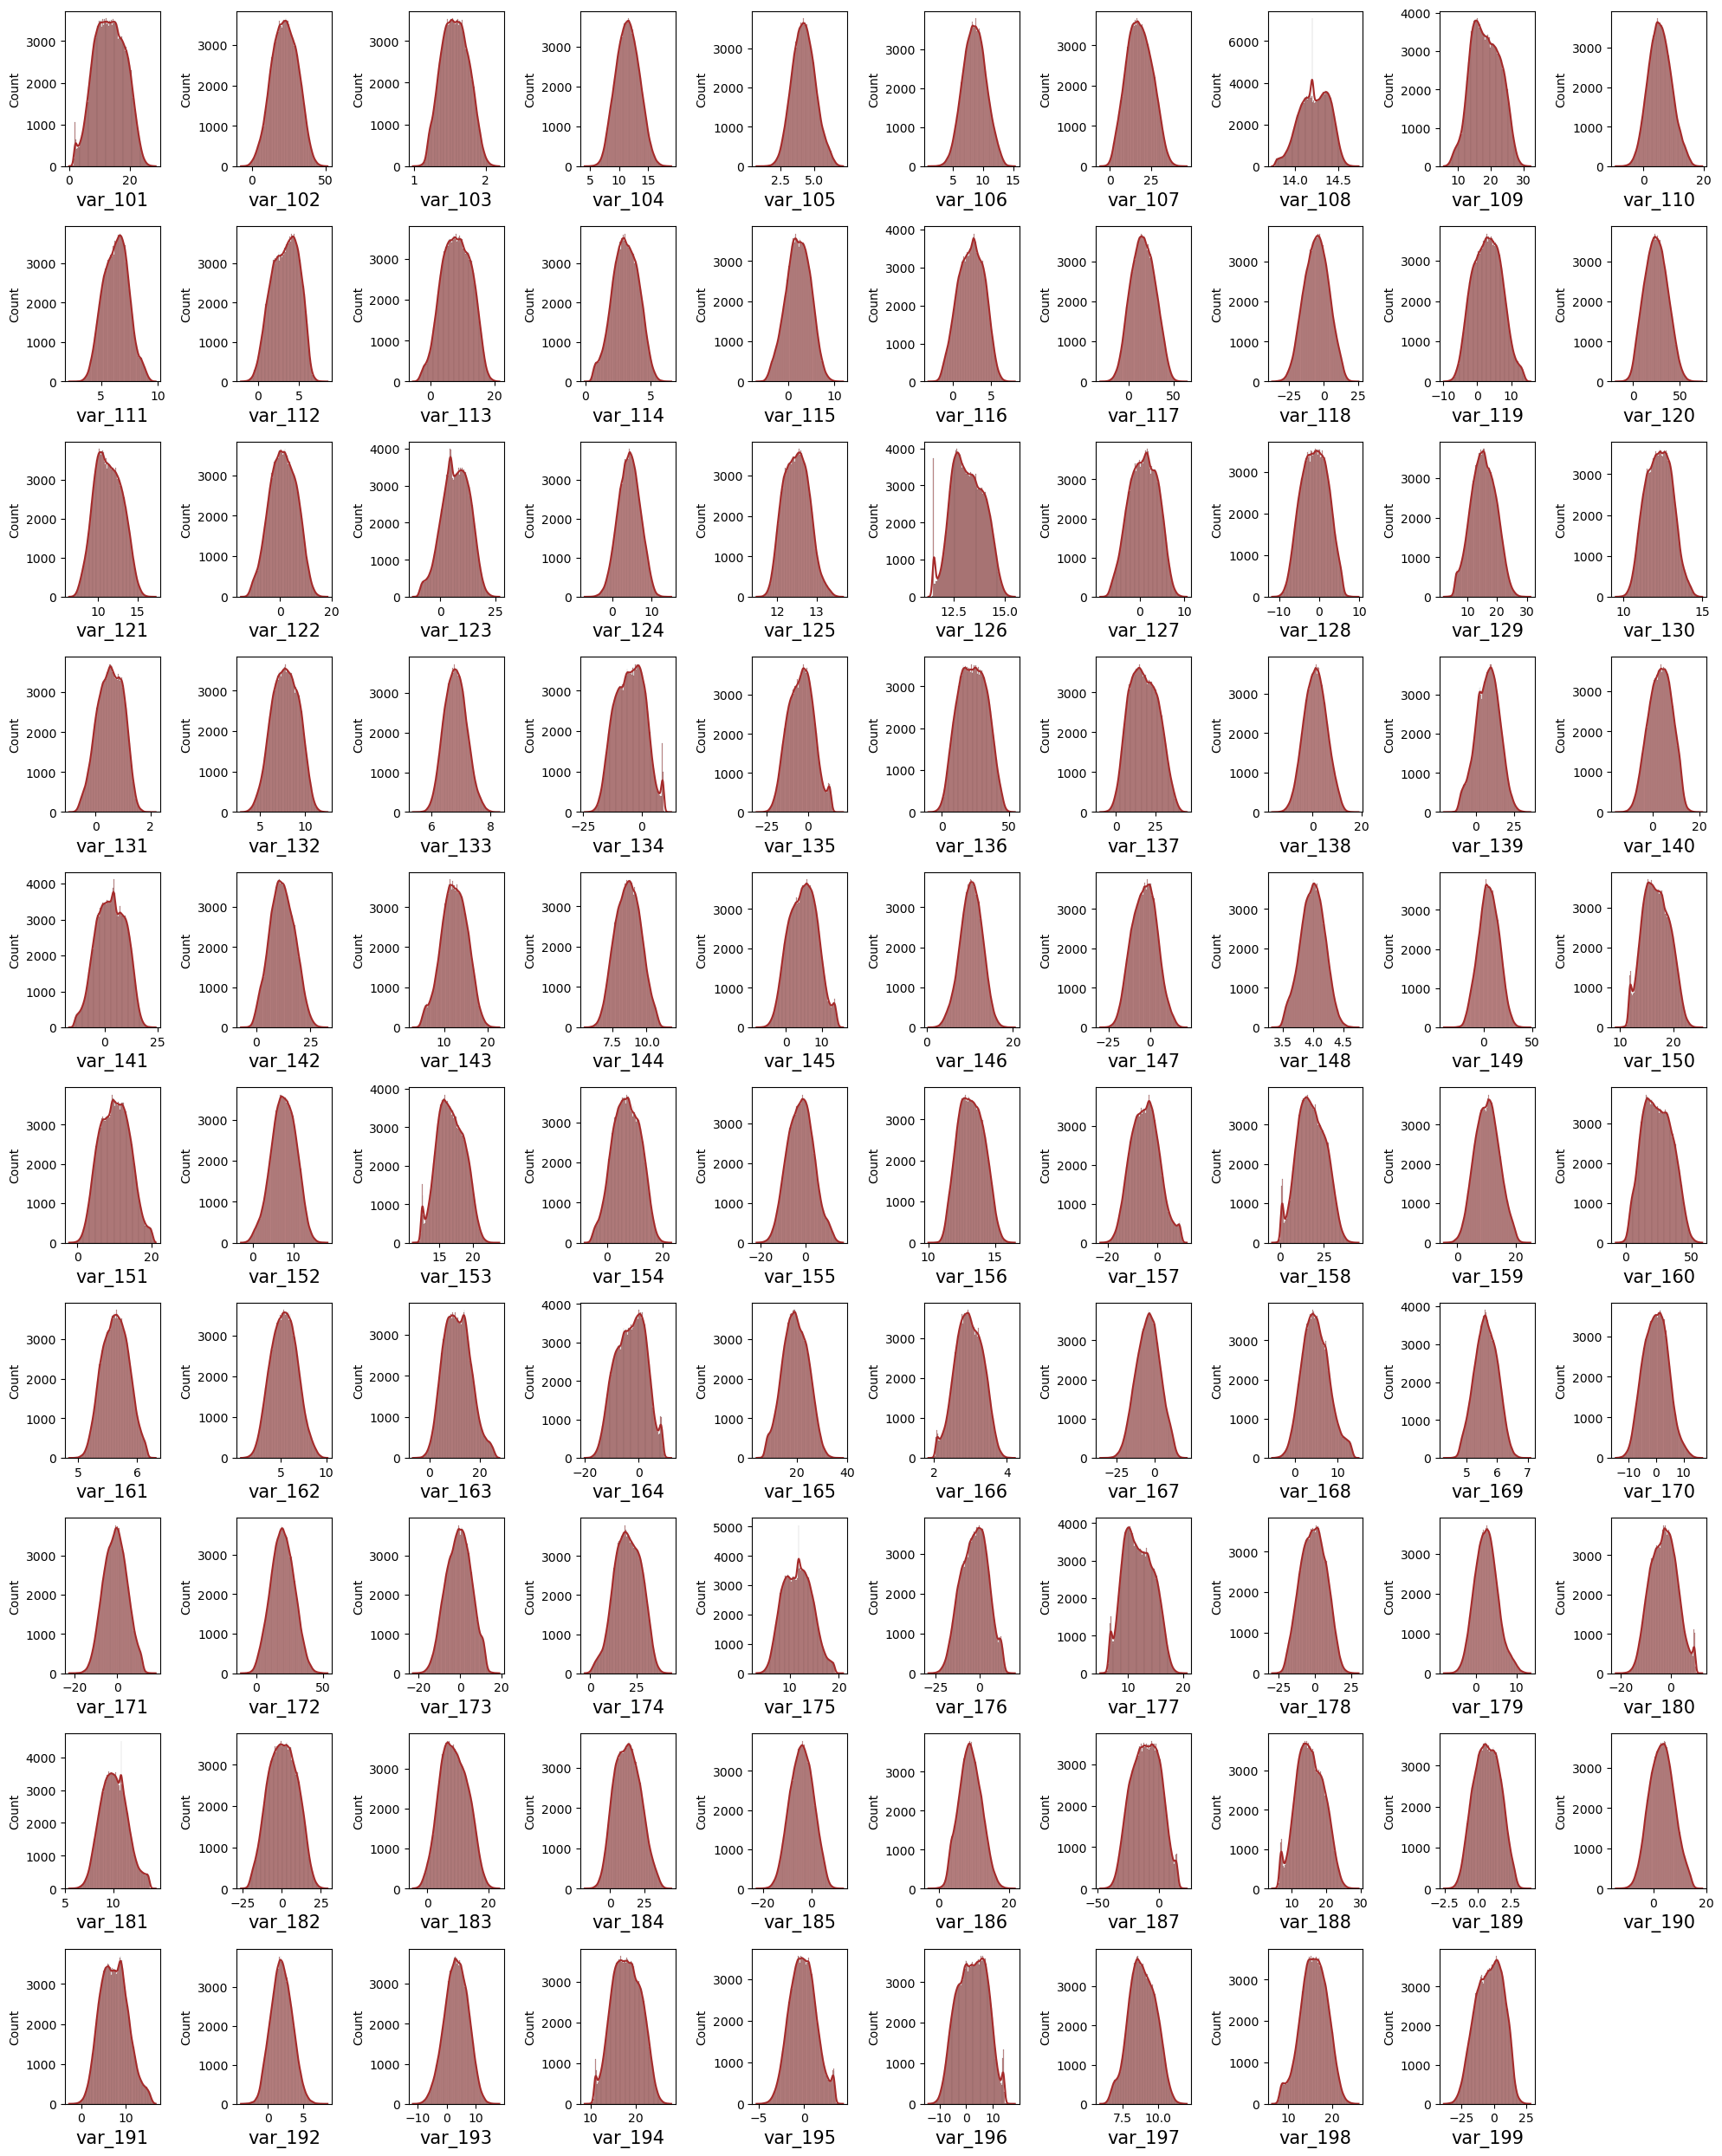

In [14]:
dist1 = df.iloc[:,103:]
plt.figure(figsize=(20,25),facecolor='white') 
plotno = 1 
for column in dist1: 
    if plotno<=100: 
        plt.subplot(10,10,plotno) 
        sns.histplot(dist1[column],kde=True,color='brown')
        plt.xlabel(column,fontsize=15) 
    plotno+=1
plt.tight_layout()
plt.show() 

In [15]:
# Calculate skewness for feature columns
features = df.drop(columns=['ID_code', 'target'])
skewness = features.skew()

# Max and Min skewness
max_skew_col = skewness.idxmax()
min_skew_col = skewness.idxmin()

print("Maximum Skewness:")
print(f"Column: {max_skew_col}, Skewness Value: {skewness[max_skew_col]}")

print("\nMinimum Skewness:")
print(f"Column: {min_skew_col}, Skewness Value: {skewness[min_skew_col]}")


Maximum Skewness:
Column: var_168, Skewness Value: 0.2674136233473473

Minimum Skewness:
Column: var_44, Skewness Value: -0.34017215733706146


### Excluding the ID_code column, the input features show very low skewness values ranging between −0.34 and 0.27. Additionally, histogram visualizations shows bell-shaped curves, indicating that most variables are approximately symmetric and close to a normal distribution.Due to this no transformation is required

# Checking Outliers

In [4]:
from scipy.stats import zscore

features = df.drop(columns=['ID_code', 'target'])

# Calculate Z-scores
z_scores = np.abs(zscore(features))

outliers = z_scores > 3

total_outliers = np.sum(outliers)

print("Total number of outliers in the dataset:", total_outliers)


Total number of outliers in the dataset: 11299


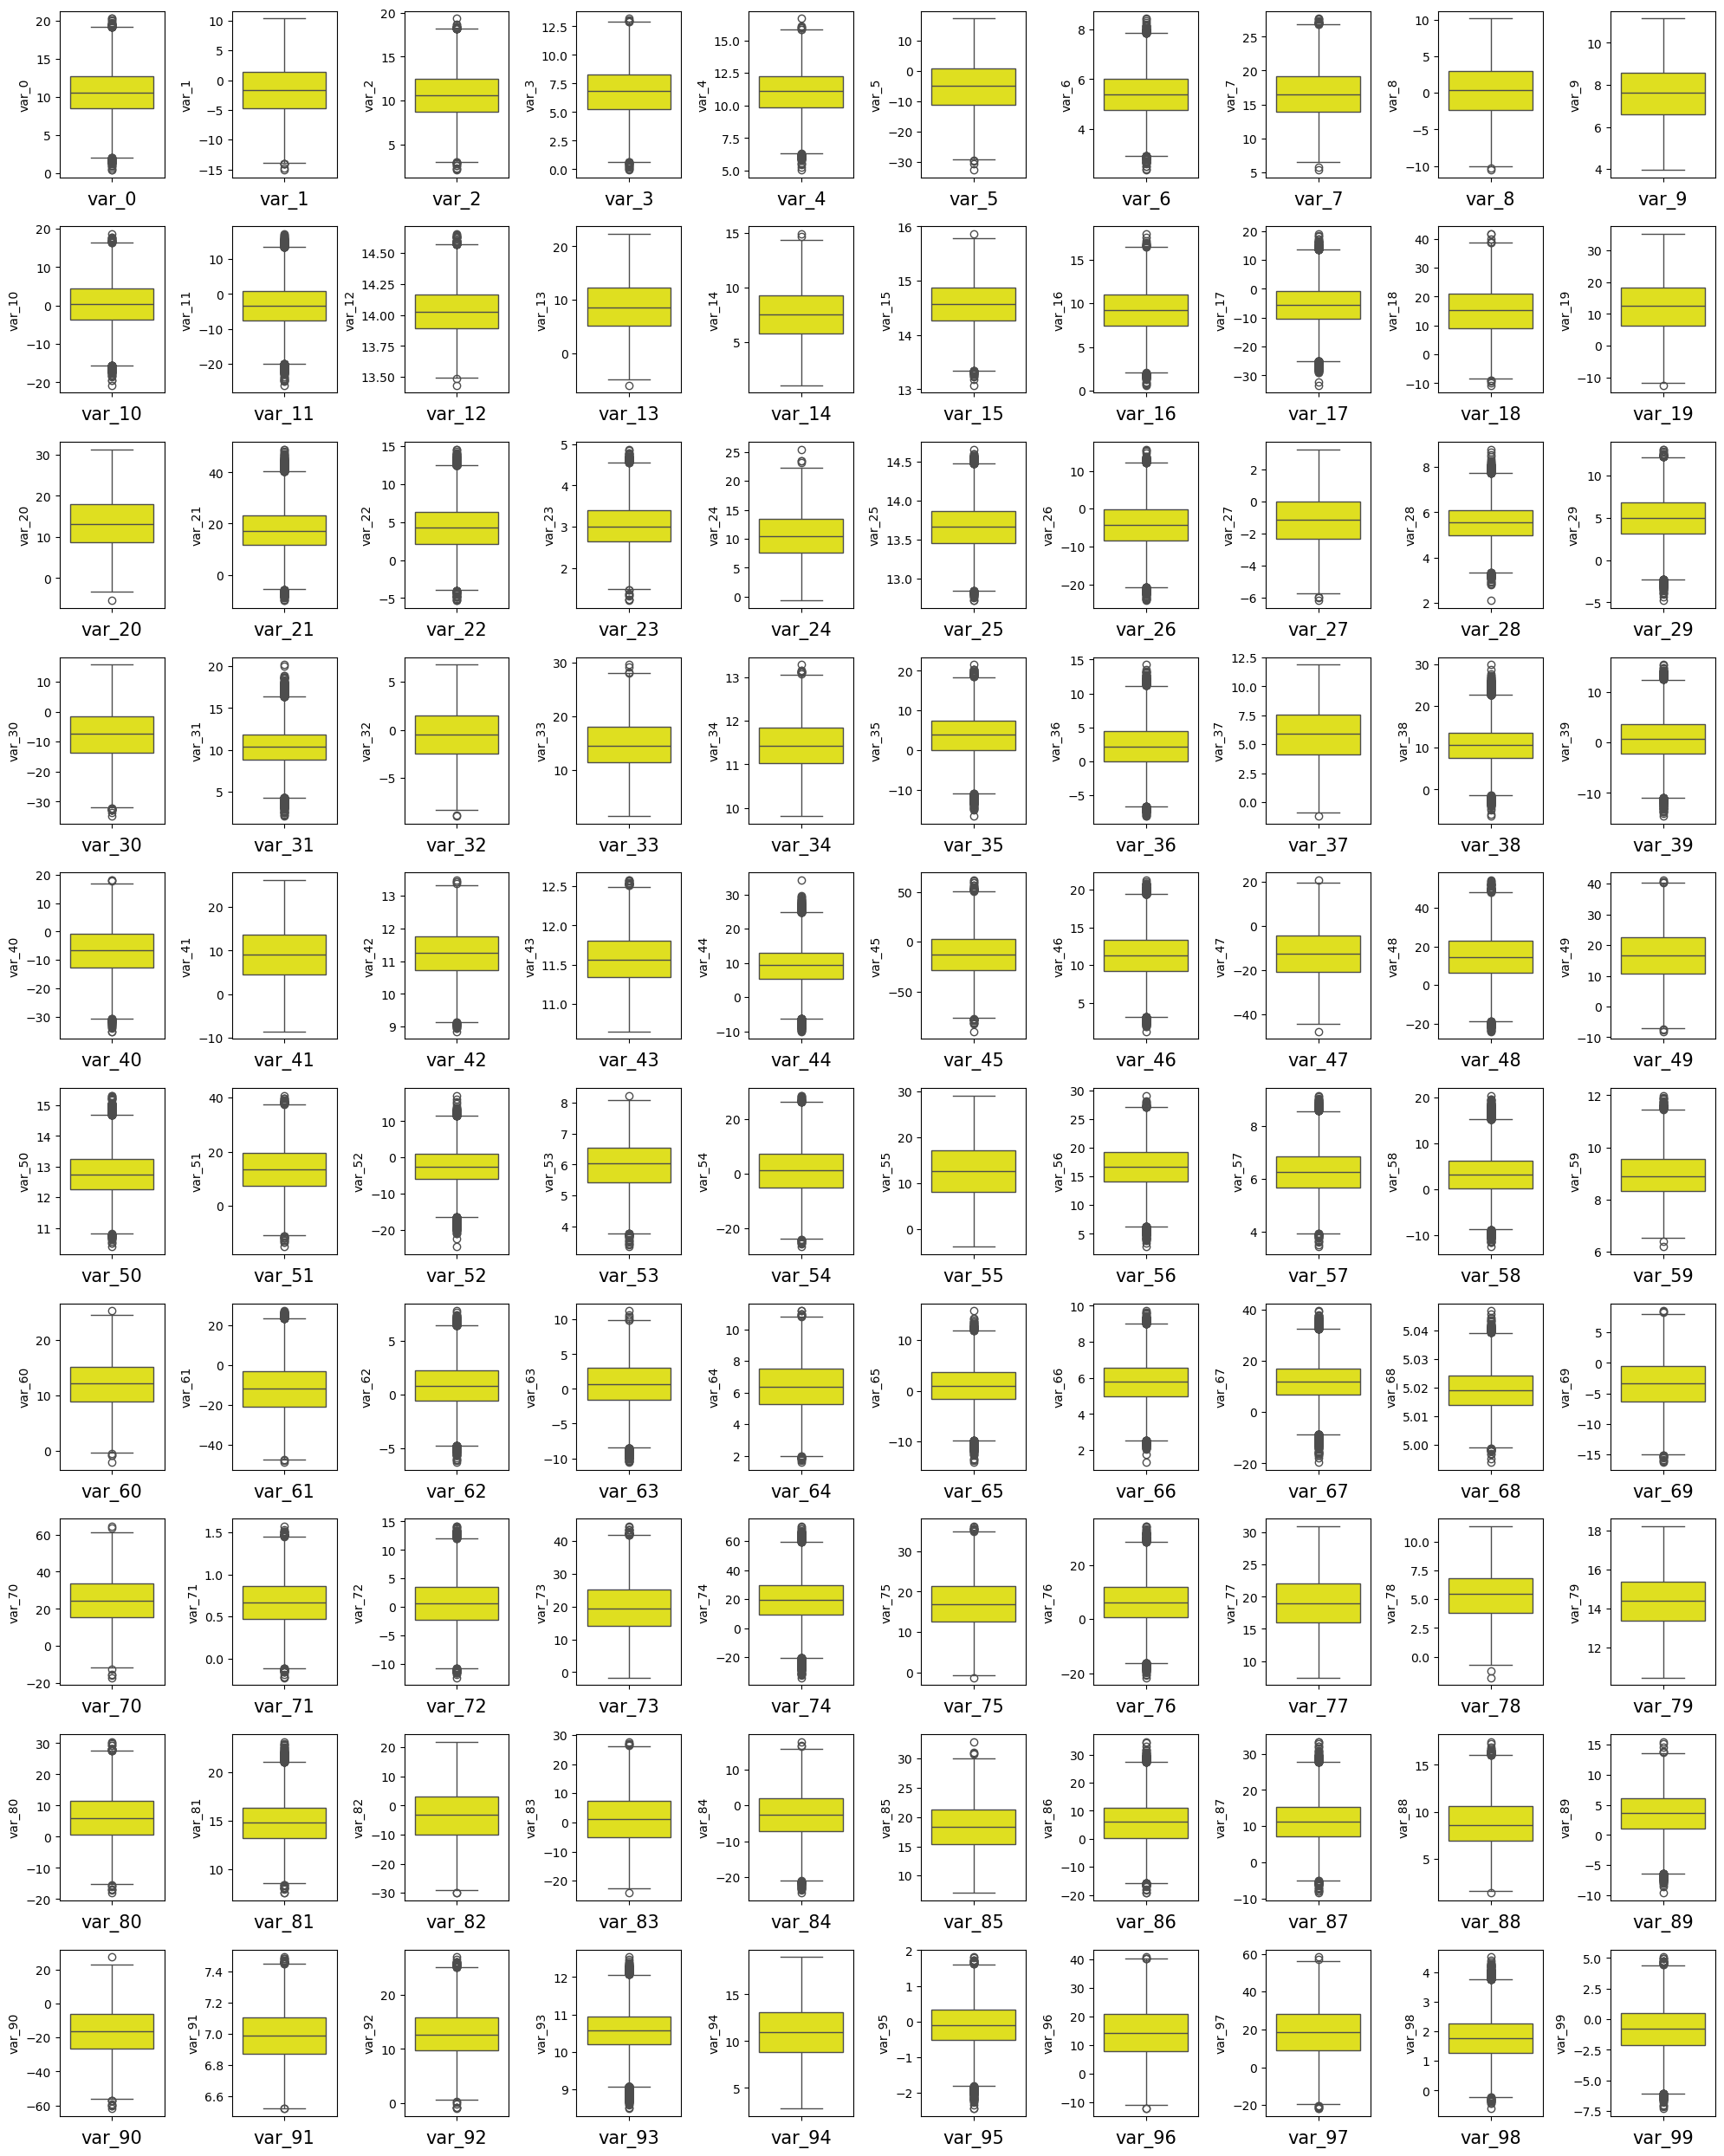

In [18]:
df_out_1 = df.iloc[:,2:102]
plt.figure(figsize=(20,25),facecolor='white') 
plotno = 1 # counter
for column in df_out_1: 
    if plotno<=100: 
        plt.subplot(10,10,plotno) 
        sns.boxplot(df_out_1[column], color="yellow")
        plt.xlabel(column,fontsize=15) 
    plotno+=1
plt.tight_layout()
plt.show() 

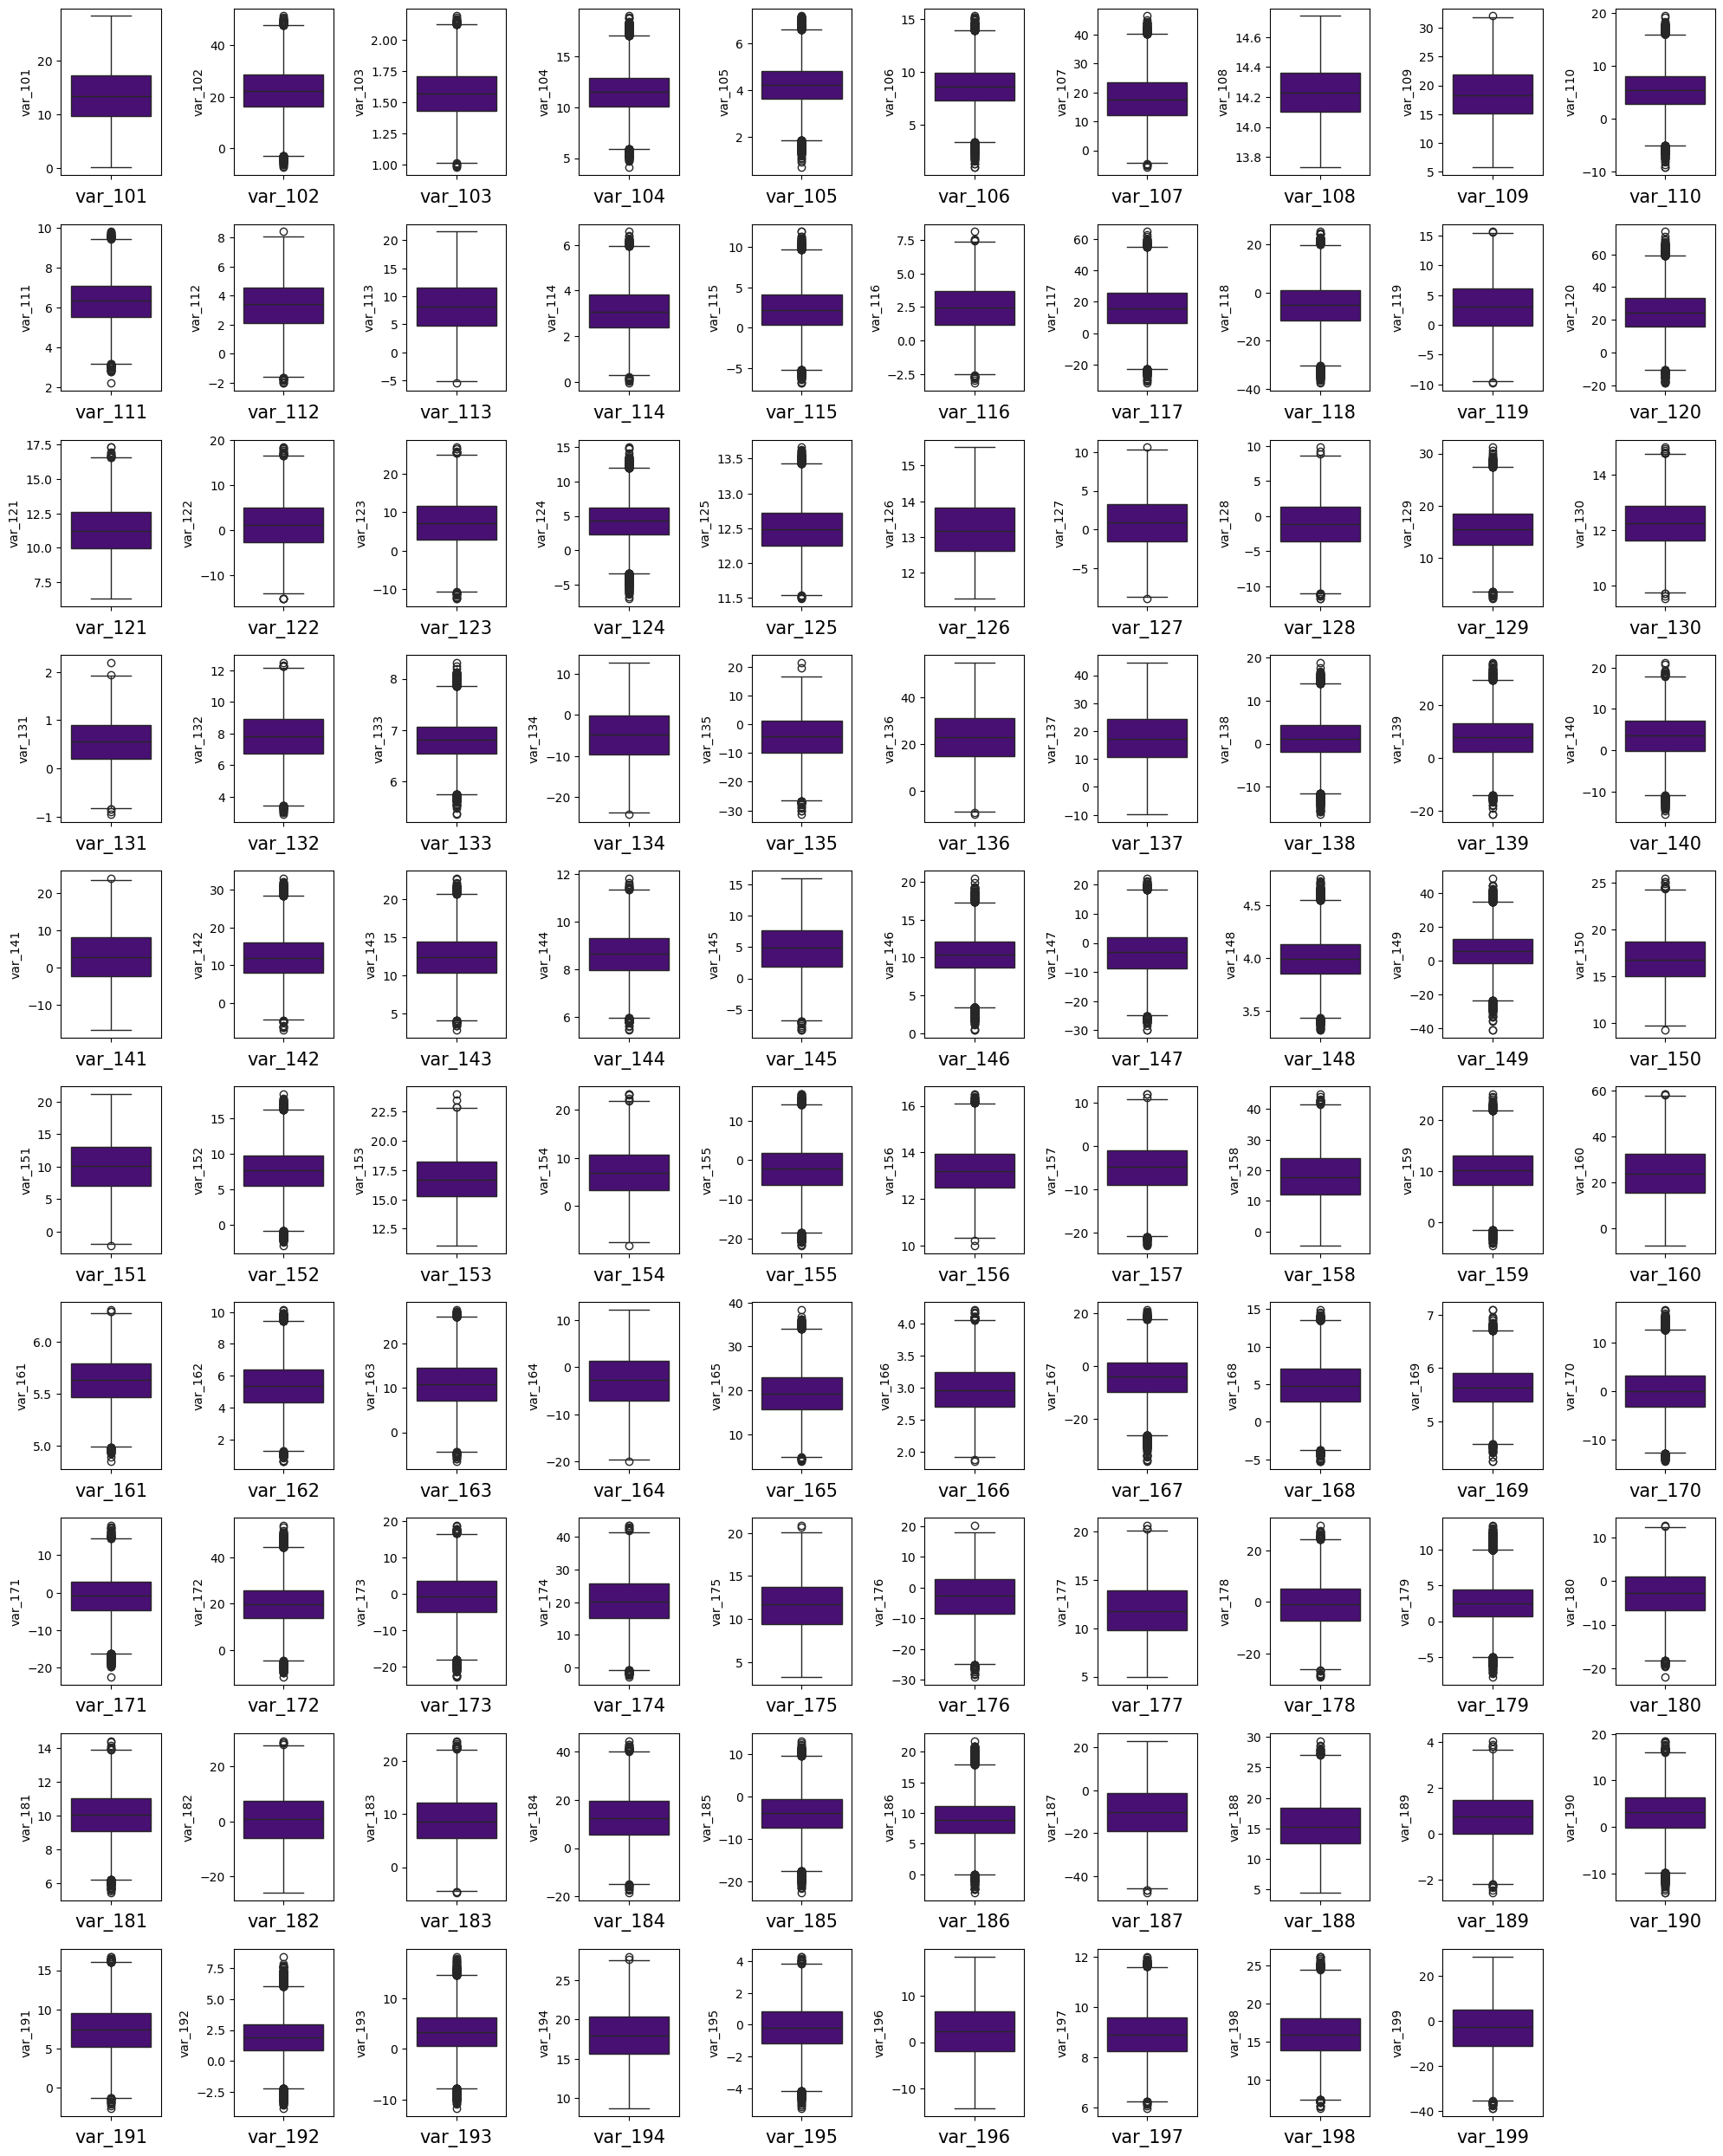

In [19]:
df_out_2 = df.iloc[:,103:]
plt.figure(figsize=(20,25),facecolor='white') 
plotno = 1 
for column in df_out_2: 
    if plotno<=100: 
        plt.subplot(10,10,plotno) 
        sns.boxplot(df_out_2[column],color='indigo')
        plt.xlabel(column,fontsize=15) 
    plotno+=1
plt.tight_layout()
plt.show() 

#### **Although a few extreme values were detected using boxplots and Z-score analysis, these observations were retained as they represent valid transaction behavior rather than data errors. To minimize their influence on distance-based models, RobustScaler will be applied instead of removing or capping outliers.**

# Feature Selection

- **We will drop the "ID_code" column as it an identifier column and of no use in prediction.**
- **"target" is our Target column so we will seperate it and store it in a y variable.**
- **Other input columns from "var_0" to "var_199" will be kept in X and a robust scaler will be applied and later we will take the help of PCA to reduce the curse of dimentionality.**

In [20]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [21]:
df.drop('ID_code',axis=1,inplace=True)

# checking correlation

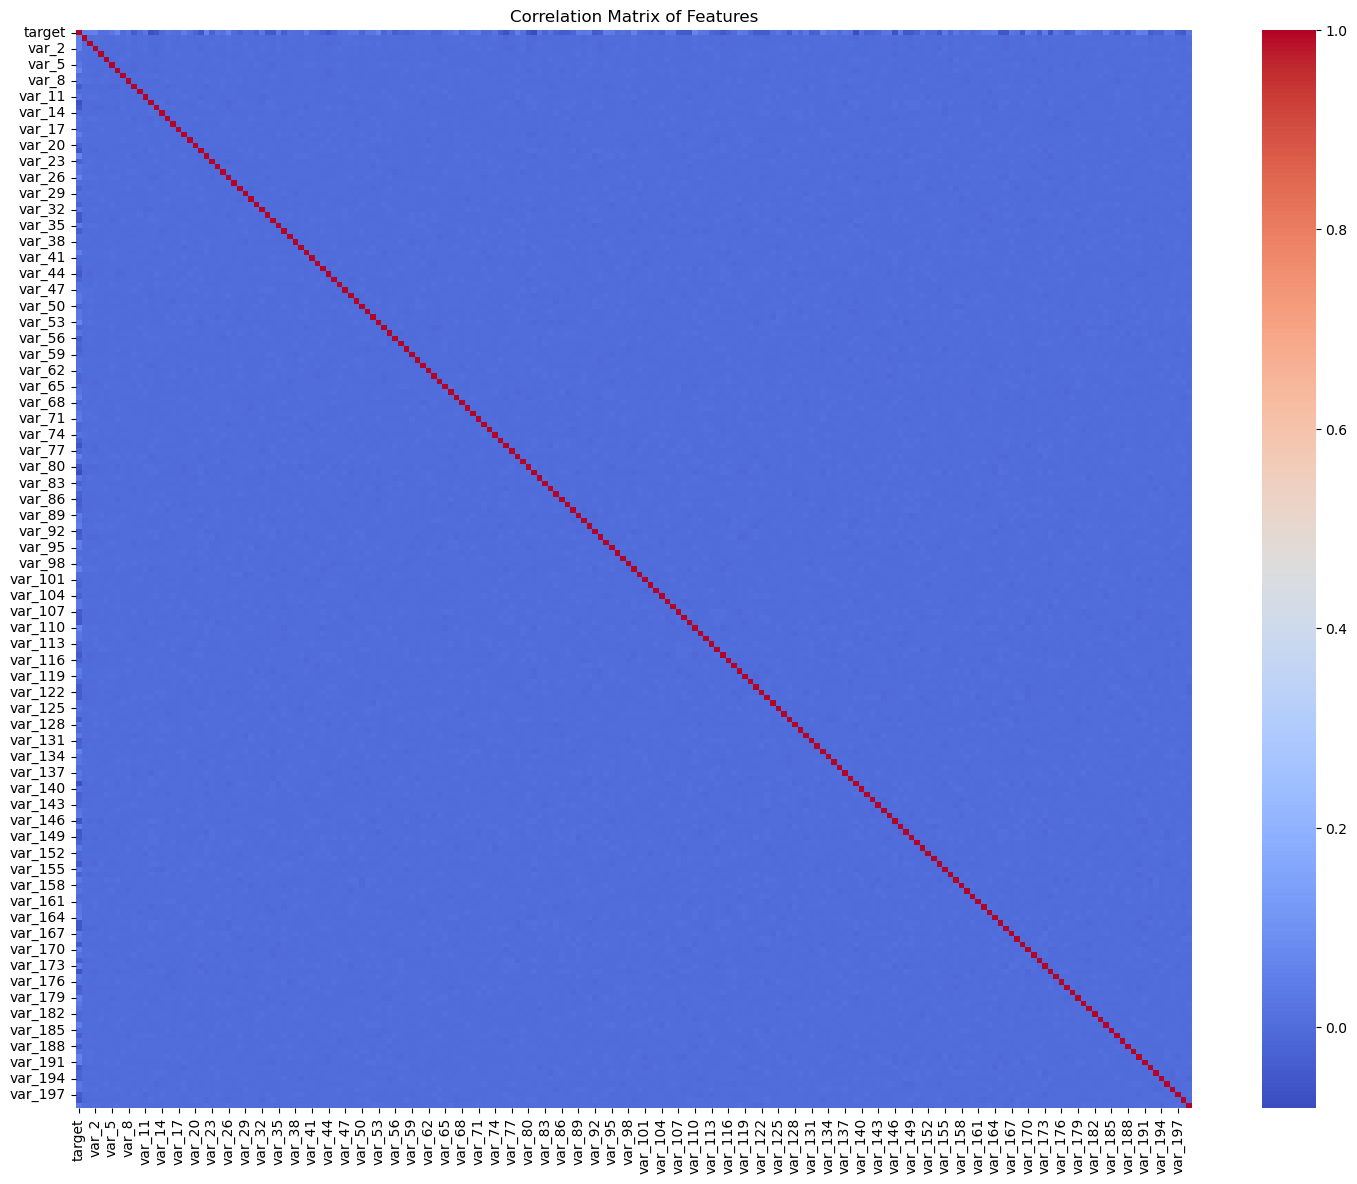

In [22]:
corr_matrix = df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

### **The heatmap indicates low correlation among most features, with no strong relationships observed. This suggests minimal multicollinearity in the dataset.**

# Separating Features and target

In [23]:
X = df.drop(columns=['target'])
Y = df["target"]

# Train-Test Spllit

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Applying RobustScaler

In [25]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)        


In [26]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

**RobustScaler is preferred as it minimizes the effect of outliers, unlike MinMaxScaler and StandardScaler which are sensitive to extreme values.**

# PCA - Principal Component Analysis

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [28]:
print("Original features:", X_train_scaled.shape[1])
print("Reduced features after PCA:", X_train_pca.shape[1])

Original features: 200
Reduced features after PCA: 189


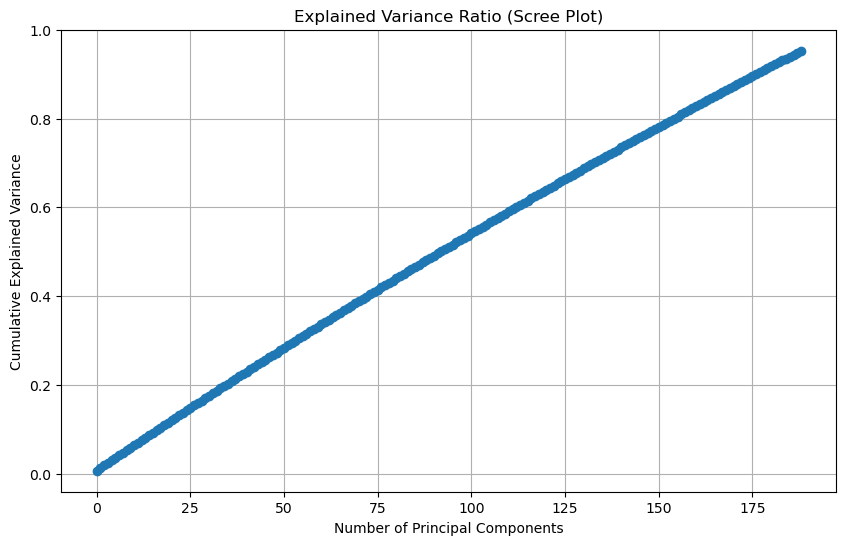

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio (Scree Plot)')
plt.grid(True)
plt.show()

In [30]:
np.where(np.cumsum(pca.explained_variance_ratio_)>=0.95)

(array([188]),)

In [31]:
final_pca = PCA(n_components=188, random_state=42)

final_X_train_pca = final_pca.fit_transform(X_train_scaled)
final_X_test_pca = final_pca.transform(X_test_scaled)

# Convert PCA output to DataFrame
final_X_train_pca = pd.DataFrame(
    final_X_train_pca,
    index=X_train_scaled.index,
    columns=[f'PC{i+1}' for i in range(188)]
)

final_X_test_pca = pd.DataFrame(
    final_X_test_pca,
    index=X_test_scaled.index,
    columns=[f'PC{i+1}' for i in range(188)]
)

print("Final PCA shape (Train):", final_X_train_pca.shape)
print("Final PCA shape (Test):", final_X_test_pca.shape)

Final PCA shape (Train): (160000, 188)
Final PCA shape (Test): (40000, 188)


**PCA retained 95% variance with 188 components, showing that information is spread across many features. This helped reduce multicollinearity while maintaining most of the original data information.**

# Model Building

## Logistic regression

In [32]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

log_reg.fit(final_X_train_pca, Y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [33]:
y_prob = log_reg.predict_proba(final_X_test_pca)[:,1]

import numpy as np
y_pred_new = np.where(y_prob > 0.7, 1, 0)

from sklearn.metrics import classification_report
print(classification_report(Y_test, y_pred_new))


              precision    recall  f1-score   support

           0       0.95      0.91      0.93     35980
           1       0.42      0.57      0.49      4020

    accuracy                           0.88     40000
   macro avg       0.69      0.74      0.71     40000
weighted avg       0.90      0.88      0.89     40000



In [34]:
from sklearn.metrics import roc_auc_score
print("Test ROC-AUC:", roc_auc_score(Y_test, y_prob))

Test ROC-AUC: 0.8594218388325191


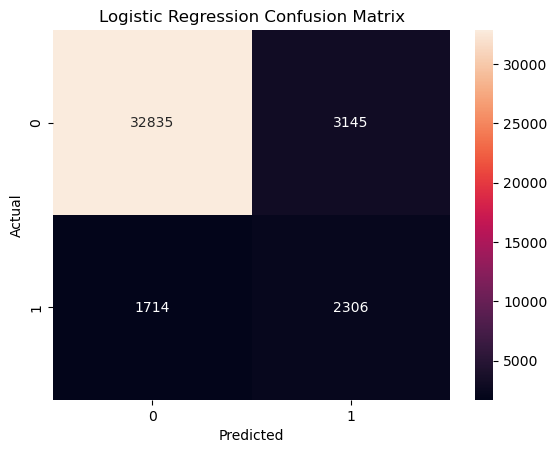

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred_new)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# RandomForest

#### Tree-based models like Decision Tree, Random Forest, and XGBoost do not need PCA because they are not distance-based algorithms. They automatically select important features and handle correlated variables well. Using PCA can remove useful information and reduce interpretability, which may lower performance.

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [37]:
y_pred_rf = rf.predict(X_test_scaled)

In [38]:
print("Random Forest Classification Report:")
print(classification_report(Y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     35980
           1       0.37      0.44      0.40      4020

    accuracy                           0.87     40000
   macro avg       0.65      0.68      0.66     40000
weighted avg       0.88      0.87      0.87     40000



In [39]:
from sklearn.metrics import roc_auc_score
y_test_prob_rf  = rf.predict_proba(X_test_scaled)[:, 1]
print("Test ROC-AUC:", roc_auc_score(Y_test, y_test_prob_rf))

Test ROC-AUC: 0.8046830121211617


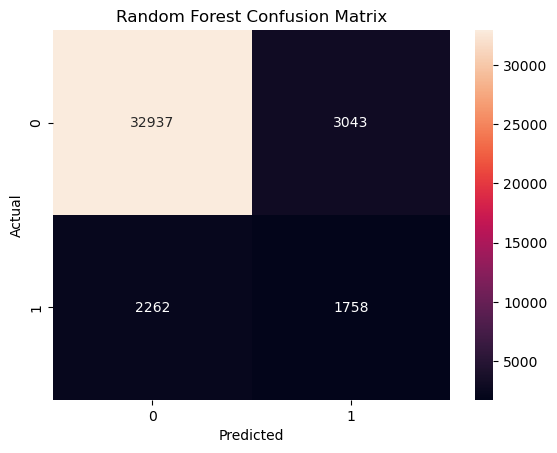

In [40]:
cm = confusion_matrix(Y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# XGBoost

In [41]:
from xgboost import XGBClassifier

xgb1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=9,   
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb1.fit(X_train_scaled, Y_train)

y_pred_xgb1 = xgb1.predict(X_test_scaled)


In [42]:
print("XGBoost Classification Report:")
print(classification_report(Y_test, y_pred_xgb1))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92     35980
           1       0.40      0.64      0.49      4020

    accuracy                           0.87     40000
   macro avg       0.68      0.77      0.71     40000
weighted avg       0.90      0.87      0.88     40000



In [43]:
y_test_prob_xgb  = xgb1.predict_proba(X_test_scaled)[:, 1]
print("Test ROC-AUC:", roc_auc_score(Y_test, y_test_prob_xgb))

Test ROC-AUC: 0.8692501915104853


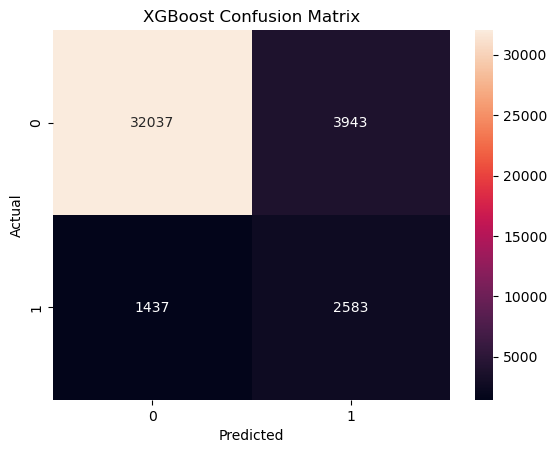

In [44]:
cm = confusion_matrix(Y_test, y_pred_xgb1)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# DecisionTree

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt = DecisionTreeClassifier(
    criterion='gini',           
    splitter='best',             
    max_depth=None,             
    min_samples_split=2,         
    min_samples_leaf=1,          
    min_weight_fraction_leaf=0.0,
    max_features=None,           
    random_state=42,             
    max_leaf_nodes=None,         
    min_impurity_decrease=0.0,   
    class_weight='balanced',    
    ccp_alpha=0.0                
)

dt.fit(X_train_scaled, Y_train)


y_pred2 = dt.predict(X_test_scaled)



In [46]:
print("DecisionTree Classification Report:")
print(classification_report(Y_test, y_pred2))

DecisionTree Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     35980
           1       0.17      0.17      0.17      4020

    accuracy                           0.83     40000
   macro avg       0.54      0.54      0.54     40000
weighted avg       0.83      0.83      0.83     40000



In [47]:
y_test_prob_dt  = dt.predict_proba(X_test_scaled)[:, 1]
print("Test ROC-AUC:", roc_auc_score(Y_test, y_test_prob_dt))

Test ROC-AUC: 0.5373105982040879


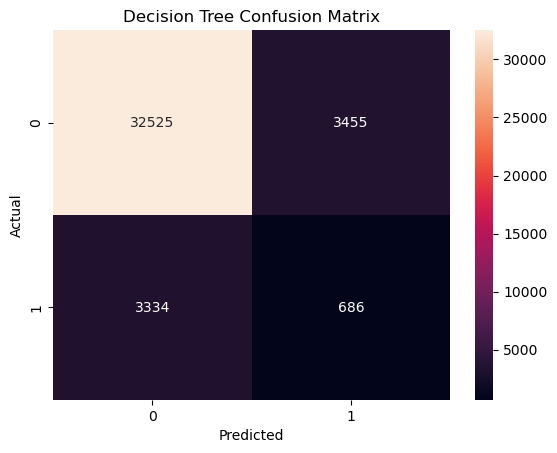

In [48]:
cm = confusion_matrix(Y_test, y_pred2)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📊 Customer Transaction Prediction Report

---

## 🎯 Objective

The objective of this project is to build a predictive machine learning model that helps the bank identify which customers are likely to make transactions in the future. Since the dataset is imbalanced, special focus is given to improving detection of the minority class while maintaining overall model performance.

---

## ⚠ Challenges Faced in the Data and Techniques Used

### 1️⃣ Class Imbalance

**Challenge:**
The dataset was highly imbalanced, with a significantly higher number of Class 0 samples compared to Class 1. This caused models to become biased toward the majority class and perform poorly in detecting minority cases.

**Techniques Used:**

* Applied `class_weight='balanced'` in Logistic Regression and Decision Tree
* Used `scale_pos_weight` in XGBoost
* Focused on improving Recall and F1-score for Class 1

---

### 2️⃣ Misleading Accuracy

**Challenge:**
Due to imbalance, models showed high accuracy even when they failed to correctly predict minority class instances, making accuracy an unreliable metric.

**Techniques Used:**

* Used ROC-AUC as the primary evaluation metric
* Evaluated Precision, Recall, and F1-score
* Compared models based on minority class performance

---

### 3️⃣ Presence of Outliers

**Challenge:**
Some features contained outliers that could negatively impact model performance, especially for algorithms sensitive to extreme values.
**Techniques Used:**

* Applied Robust Scaler to reduce outlier impact
* Avoided removing data points to retain information

---

### 4️⃣ High Dimensionality

**Challenge:**
The dataset contained a large number of features, which increased model complexity and computational cost.

**Techniques Used:**

* Applied PCA retaining 95% variance for linear models
* Used original features for tree-based models

---

### 5️⃣ Model Bias Toward Majority Class

**Challenge:**
Some models predicted majority class more frequently, resulting in low recall for minority class.

**Techniques Used:**

* Threshold tuning using probabilities
* Compared multiple algorithms

---

## 🤖 Models Evaluated

* Logistic Regression
* Decision Tree classifier
* Random Forest classifier
* XGBoost classifier

---

## 📏 Evaluation Metrics

* Accuracy
* Precision
* Recall
* F1-Score
* **ROC-AUC Score (Primary Metric)**

---

## 📈 Why ROC-AUC Was Used as Primary Metric

* Dataset is highly imbalanced
* Accuracy can be misleading
* Measures ability to distinguish transaction vs non-transaction customers
* Evaluates performance across all thresholds
* Reflects true class separation ability
* Ensures effective identification of transaction-likely customers

---

# 📊 Model Performance Summary

---

## 🔹 Logistic Regression
- Accuracy: 0.88
- Precision (Class 1): 0.42
- Recall (Class 1): 0.57
- F1-Score (Class 1): 0.49
- ROC-AUC: 0.86

**Interpretation:**
The Logistic Regression model achieved 88% accuracy, but due to class imbalance, the focus is on minority class performance. With precision of 0.42 and recall of 0.57, the model shows moderate ability to correctly identify customers who will make transactions. The ROC-AUC score of 0.86 indicates strong class separation, making the model a reliable baseline.

---

## 🔹 Random Forest classifier
- Accuracy: 0.87
- Precision (Class 1): 0.37
- Recall (Class 1): 0.44
- F1-Score (Class 1): 0.40
- ROC-AUC: 0.80
|
**Interpretation:**
The Random Forest model achieved 87% accuracy, but minority class detection remains moderate due to class imbalance. With precision of 0.37 and recall of 0.44, the model shows limited ability to correctly identify customers who will make transactions. The ROC-AUC score of 0.80 indicates good class separation, though slightly lower than Logistic Regression.

---

## 🔹 XGBoost classifier

- Accuracy: 0.87
- Precision (Class 1): 0.40
- Recall (Class 1): 0.64
- F1-Score (Class 1): 0.49
- ROC-AUC: 0.86
**Interpretation:**
The XGBoost model achieved 87% accuracy and shows improved detection of transaction customers with a recall of 0.64, indicating it captures more actual positives. With precision of 0.40 and F1-score of 0.49, the model provides a balanced performance between detecting and correctly predicting the minority class. The ROC-AUC score of 0.86 indicates strong class separation, making it a competitive model for this task.

---

## 🔹 Decision Tree classifier
- Accuracy: 0.83
- Precision (Class 1): 0.18
- Recall (Class 1): 0.19
- F1-Score (Class 1): 0.18
- ROC-AUC: 0.53
**Interpretation:**
The Decision Tree model achieved 83% accuracy, but this is misleading due to very poor minority class performance. With precision of 0.18 and recall of 0.19, the model struggles to correctly identify customers who will make transactions. The ROC-AUC score of 0.53 indicates weak class separation, suggesting the model is not suitable for this problem.

---

# 📊 Final Model Comparison

| Model               | Accuracy | Precision | Recall | F1-Score | ROC-AUC | Observation          |
| ------------------- | -------- | --------- | ------ | -------- | ------- | -------------------- |
| Logistic Regression | 0.88     | 0.42      | 0.57   | 0.49     | 0.86    | Balanced performance |
| Random Forest       | 0.87     | 0.37      | 0.44   | 0.40     | 0.80    | Moderate performance |
| XGBoost             | 0.87     | 0.40      | 0.64   | 0.49     | 0.86    | Best recall          |
| Decision Tree       | 0.83     | 0.18      | 0.19   | 0.18     | 0.53    | Poor performance     |

---

## 🏁 Final Conclusion

In this project, multiple machine learning models were evaluated to predict which customers are likely to make transactions in the future using an imbalanced dataset. ROC-AUC was used as the primary evaluation metric to ensure reliable assessment of class separation ability. Among all models, XGBoost and Logistic Regression demonstrated the best overall performance with strong ROC-AUC scores and balanced F1-scores for the minority class, while Decision Tree performed poorly due to weak class separation. Therefore, XGBoost is considered the most suitable model as it achieved the highest recall for transaction customers while maintaining good overall performance, making it effective for identifying potential transaction behavior.


